<a href="https://colab.research.google.com/github/marcos-mansur/load-forecast/blob/main/Notebook_8_hyperptuning_LSTM_base_em_dias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pendulum
!pip install optuna

In [5]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import timeseries_dataset_from_array
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pendulum
import optuna

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = False


# Load Files

In [6]:
df_20XX = pd.read_csv(f'https://ons-dl-prod-opendata.s3.amazonaws.com/dataset/carga_energia_di/CARGA_ENERGIA_2009.csv', 
                      sep=';', 
                      parse_dates=['din_instante'])

for x in range(2010,2021):
  df_20XX = pd.concat(objs = (df_20XX,pd.read_csv(f'https://ons-dl-prod-opendata.s3.amazonaws.com/dataset/carga_energia_di/CARGA_ENERGIA_{x}.csv', 
                      sep=';', 
                      parse_dates=['din_instante'])))

load_col = 'val_cargaenergiamwmed'
time_col = 'din_instante'

# Treat data

In [7]:
def get_friday(date_time): 
  """ get next friday = start the operative week"""
  
  # today
  dt = pendulum.datetime(date_time.year,date_time.month, date_time.day)
  # return next friday
  return  dt.next(pendulum.FRIDAY).strftime('%Y-%m-%d')


def treat_data(df,regiao='SUDESTE',operative_week_start=2):
  
  # round the values of load
  df['val_cargaenergiamwmed'] = np.round(df['val_cargaenergiamwmed'],2)
  # drop last 4 rows that doesn't have load values
  df.dropna(axis=0, how='any',inplace=True)
  # filter data by subsystem 
  try:
    df = df[df['nom_subsistema']==regiao].reset_index().drop('index',axis=1).copy()
  except:
    pass
  # dropa colunas sobre região
  df.drop(labels=['nom_subsistema','id_subsistema'], inplace=True, axis=1,errors='ignore')


  # get next friday - begins the operative week
  next_fri = get_friday(df['din_instante'].iloc[0])
  # df starts with the begin of operative week
  df = df[df['din_instante'] >= next_fri].copy()

  # create column with week number 
  df.reset_index(inplace=True,drop=True)
  df['semana'] = (df.index)//7 
  
  return df

df = treat_data(df_20XX, regiao='SUDESTE')
df.head(3)

,din_instante,val_cargaenergiamwmed,semana
0,2009-01-02,26104.57,0
1,2009-01-03,25754.14,0
2,2009-01-04,23795.99,0


# Visualize raw data

In [9]:
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['axes.grid'] = False

<function matplotlib.pyplot.show>

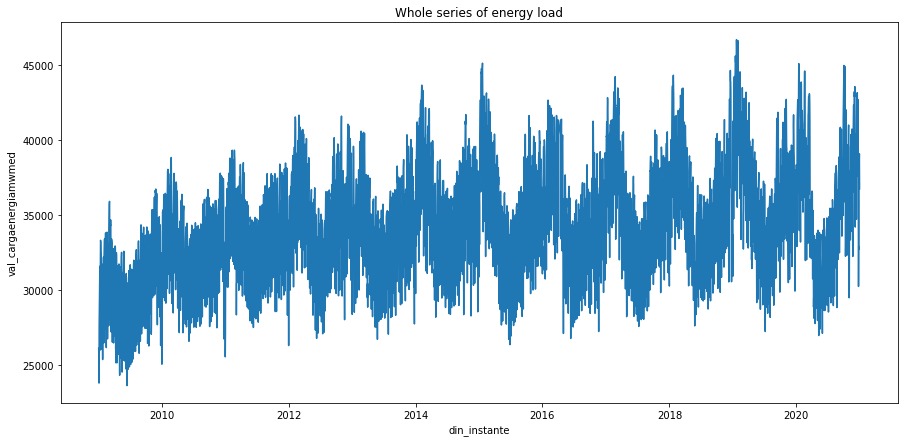

In [278]:
fig, ax = plt.subplots(figsize=(15,7))
sns.lineplot(x=pd.to_datetime(df[time_col]),y=df[load_col],ax=ax)
ax.set_title('Whole series of energy load')
plt.show

# Initialize constants

In [346]:
batch_size = 32
# target days to sum into weeks
target_period = 7 
# window size for each sample
window_size = 7*20
filepath = 'NB8.h5'

shuffle_buffer = 20
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('window_size = ',window_size)

window_size =  140


In [ ]:
# average daily load by operative week
df_target = pd.DataFrame(data=df.groupby(by=['semana'])['val_cargaenergiamwmed'].mean())
# start day of each operative week
df_target['Data'] = df.groupby(by=['semana'])['din_instante'].min()

# Split train test

In [182]:
def split_time(df,
               split_val = split_val, 
               split_test = split_test):
  # split datasets
  train_df = df[0:split_val]
  val_df = df[split_val:split_test]
  test_df = df[split_test:]
  
  return train_df, val_df, test_df

train_df, val_df, test_df = split_time(df)

# index of end of training dataset, start of validation dataset
split_val = int(len(df)*0.7)
# index of end of validation dataset, start of test dataset
split_test = int(len(df)*0.9)

# date when starts the validation and test sets 
date_val = df.iloc[split_val][time_col]
date_test = df.iloc[split_test][time_col]
# window_size date interval
delta_window = pd.to_timedelta(window_size,unit='d')
# split validation data date + window_size
d2 = date_val + delta_window
# split test data date + window_size
d3 = date_test + delta_window 

In [ ]:
def plot_serie(df1, col = load_col ,start=0,end=None, title=''):
  plt.rcParams['figure.figsize'] = [15,6]
  plt.plot(df1[time_col][start:end],
           df1[col][start:end],)
  plt.title(title + ' - energy load')
  plt.xlabel("Time")
  plt.ylabel("Value")
  plt.grid(True)
  return plt


# plot_serie(val_df)

# TensorFlow Dataset

In [347]:
def windowed_dataset(df, batch_size = batch_size, 
                     window_size = window_size, shuffle_buffer = shuffle_buffer, 
                     target_period = target_period):
  df = df.copy()
  # get next friday - begins the operative week
  next_fri = get_friday(df['din_instante'].iloc[0])
  # df starts with the begin of operative week
  df = df[df['din_instante'] >= next_fri]
  # CONSERTAR
  data_week = df[window_size:].groupby(by=['semana'])['din_instante'].min()


  series = df[load_col]
  # tf.dataset
  dataset = tf.data.Dataset.from_tensor_slices(series)
  # create windows 
  dataset = dataset.window(window_size + target_period, shift=7, drop_remainder=True)
  # make sure avery window is the same size / clip NaN at the end
  dataset = dataset.flat_map(lambda window: window.batch(window_size + target_period))
  # randomly shuffles the windows instances in the dataset 
  dataset = dataset.shuffle(shuffle_buffer)
  # separates features and target and average the target days
  dataset = dataset.map(lambda window: (window[:-target_period], 
                                        tf.math.reduce_sum(window[-target_period:]/target_period)))
  # batch
  dataset = dataset.batch(batch_size).prefetch(1)
  return dataset, data_week

train_dataset, train_data_week = windowed_dataset(df = train_df)
val_dataset, val_data_week = windowed_dataset(df = val_df)
test_dataset, teste_data_week = windowed_dataset(df = test_df)

In [ ]:
for window in train_dataset:
  print([item.numpy() for item in window])
  break

# Baseline

In [274]:
# baseline = load from last week
df_target['baseline'] = df_target[load_col].shift(1)
df_target.head()

,val_cargaenergiamwmed,Data,baseline
semana,,,
0,27536.564286,2009-01-02,NaN
1,31029.192857,2009-01-09,27536.564286
2,30444.171429,2009-01-16,31029.192857
3,29957.377143,2009-01-23,30444.171429
4,31392.350000,2009-01-30,29957.377143


In [276]:
# indexes for .loc for each set of data 
train_ix_base = ((df_target['Data'] < date_val) & (df_target['Data'] >= '2009-05-22'))
val_ix_base = ((df_target['Data'] > d2) & (df_target['Data']<date_test))
test_ix_base = df_target['Data']> d3

# metrics for baseline model
metrics_baseline = pd.DataFrame(index = ['train', 'val', 'test'], 
                       data = 

          {'MAE' : [tf.keras.metrics.mean_absolute_error(
          df_target.loc[ix][load_col][1:],
          df_target.loc[ix]['baseline'][1:]).numpy() 
          for ix in [train_ix_base, val_ix_base, test_ix_base]],

          'MSLE' : [tf.keras.metrics.msle(
          df_target.loc[ix][load_col][1:],
          df_target.loc[ix]['baseline'][1:]).numpy() 
          for ix in [train_ix_base, val_ix_base, test_ix_base]],
          
          'MAPE' : [tf.keras.metrics.mape(
          df_target.loc[ix][load_col][1:],
          df_target.loc[ix]['baseline'][1:]).numpy() 
          for ix in [train_ix_base, val_ix_base, test_ix_base]]})

metrics_baseline

,MAE,MSLE,MAPE
train,1083.174097,0.001620,3.069226
val,1243.470222,0.002152,3.383350
test,1481.775497,0.002973,4.069876


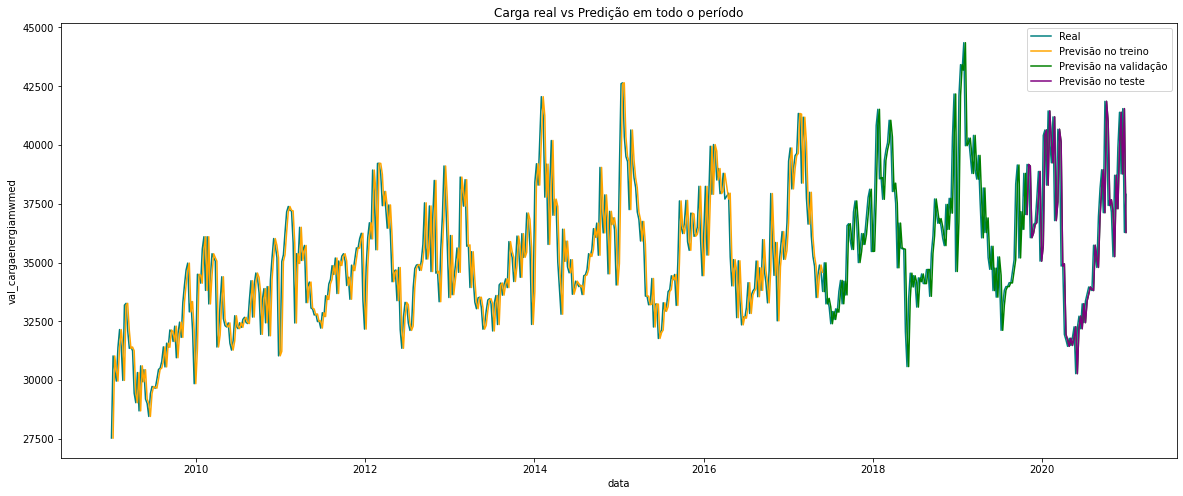

In [184]:
fix,ax=plt.subplots(figsize=(20, 8))

# plot measured data
sns.lineplot(x = df_target['data'], 
             y = df_target[load_col], 
             ax=ax, color = 'teal')

# plot predicted training data
sns.lineplot(x = df_target.loc[df_target['data']<date_val][1:].data, 
             y = df_target.loc[df_target['data']<date_val][1:].baseline,
             ax=ax, color='orange')

# plot predicted validation data
sns.lineplot(x = df_target[df_target['data']>date_val].data, 
             y = df_target[df_target['data']>date_val].baseline,
             ax=ax, color='green')
# plot predicted test data
sns.lineplot(x = df_target[df_target['data']>date_test].data, 
             y = df_target[df_target['data']>date_test].baseline,
             ax=ax, color='purple')

#plt.plot(df.din_instante[split_val:],np.array(forecast)[split_val-window_size:,0,0])
plt.title('Carga real vs Predição em todo o período')
plt.legend(['Real', 'Previsão no treino', 'Previsão na validação', 'Previsão no teste'])

# model optmization

In [360]:
# LSTM
model = tf.keras.models.Sequential([
    tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis = -1), input_shape=[None]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LSTM(124, return_sequences=True, kernel_initializer='normal', activation ='tanh'),
    tf.keras.layers.LSTM(32, return_sequences=False, kernel_initializer='normal', activation ='tanh'),
    tf.keras.layers.Dense(1),
    tf.keras.layers.Lambda(lambda x: x * 10000.0)
    ])


def create_model(trial):
    # We optimize the numbers of layers, their units and weight decay parameter.
    n_layers = trial.suggest_int("n_layers", 1, 4)
    weight_decay = trial.suggest_float("weight_decay", 1e-10, 1e-3, log=True)
    
    model = tf.keras.models.Sequential([
                        # fix dimensions
                        tf.keras.layers.Lambda(lambda x: 
                                               tf.expand_dims(x, axis = -1), 
                                               input_shape=[None]),
                        # normalize data
                        tf.keras.layers.BatchNormalization()
                        ])
    # loop to generate hidden layers
    for i in range(n_layers):
        # number of memory cells
        num_hidden = trial.suggest_int("n_units_l{}".format(i), 4, 128, log=True)
        model.add(
            tf.keras.layers.LSTM(
                num_hidden,
                activation="tanh",
                kernel_regularizer=tf.keras.regularizers.l2(weight_decay),
            )
        )
    model.add(
        tf.keras.layers.Dense(1,kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
        tf.keras.layers.Lambda(lambda x: x * 10000.0)
    )
    return model

def create_optimizer(trial):
    # We optimize the choice of optimizers as well as their parameters.
    kwargs = {}
    optimizer_options = ["RMSprop", "Adam", "SGD"]
    optimizer_selected = trial.suggest_categorical("optimizer", optimizer_options)
    if optimizer_selected == "RMSprop":
        kwargs["learning_rate"] = trial.suggest_float(
            "rmsprop_learning_rate", 1e-5, 1e-1, log=True
        )
        kwargs["decay"] = trial.suggest_float("rmsprop_decay", 0.85, 0.99)
        kwargs["momentum"] = trial.suggest_float("rmsprop_momentum", 1e-5, 1e-1, log=True)
    elif optimizer_selected == "Adam":
        kwargs["learning_rate"] = trial.suggest_float("adam_learning_rate", 1e-5, 1e-1, log=True)
    elif optimizer_selected == "SGD":
        kwargs["learning_rate"] = trial.suggest_float(
            "sgd_opt_learning_rate", 1e-5, 1e-1, log=True
        )
        kwargs["momentum"] = trial.suggest_float("sgd_opt_momentum", 1e-5, 1e-1, log=True)

    optimizer = getattr(tf.optimizers, optimizer_selected)(**kwargs)
    return optimizer


# Train model


In [ ]:
def compile_and_fit(model, data, val_data, epochs,
                    filepath=filepath, patience=4):
  # early stopping callback
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')
  # checkpoint callback
  checkpoint = ModelCheckpoint(filepath = filepath, monitor = 'loss', 
                               verbose = 1, save_best_only = True, mode = 'min')
  
  # compile
  model.compile(loss=tf.losses.MeanSquaredError(),
                optimizer=tf.optimizers.Adam(),
                metrics=[tf.metrics.MeanAbsoluteError(),
                         tf.metrics.MeanSquaredError(),
                         tf.metrics.MeanAbsolutePercentageError()])
  # fit data
  history = model.fit(data, epochs=epochs,
                      validation_data= val_data,
                      callbacks=[early_stopping]) #, checkpoint]) 
  return history

history = compile_and_fit(model, epochs = 100, 
                          data=train_dataset, 
                          val_data = val_dataset,
                          patience = 4,
                          filepath = filepath)

#print(os.listdir())

#print("Layer weights {}".format(l0.get_weights()))

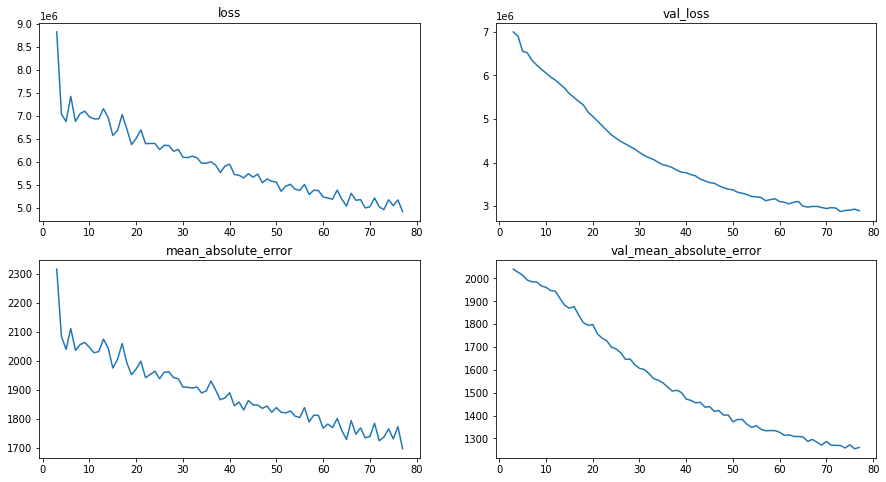

In [362]:
# evaluate training metrics

# starting epoch to plot
skip = 3

fig,ax = plt.subplots(figsize=(15,8), nrows=2, ncols=2)
metrics_list = ['loss','val_loss',
                'mean_absolute_error',
                'val_mean_absolute_error']

for i, metric in enumerate(metrics_list):
  sns.lineplot(x = range(skip,len(history.history[metric])),
              y = history.history[metric][skip:],
              ax = ax.ravel()[i])
  ax.ravel()[i].set_title(metric)

plt.show()

# Prediction

In [363]:
# forecast
forecast = []
forecast_date = []
for time in range(0,len(df) - window_size,7):
  forecast.append(model.predict(np.array(df[load_col][time:time + window_size])[np.newaxis]))
  forecast_date.append(df[time_col].iloc[time + window_size])

# unnest nested data
forecast = np.array(forecast)[:,0,0]
# dataframe with date and load
pred_result = pd.DataFrame(data = {'Data' : forecast_date, 
                                   'Carga_prev' : forecast})
# join measured target values
metrics_pred = pred_result.set_index('Data').join(df_target.set_index('Data'), 
                                                  how='left', 
                                                  on='Data').reset_index()
# evaluate performance
val_performance = {}
val_performance['LSTM'] = model.evaluate(val_dataset)
performance = {}
performance['LSTM'] = model.evaluate(test_dataset)

2/2 [==============================] - 0s 65ms/step - loss: 4228143.0000 - mean_absolute_error: 1768.5330 - mean_squared_error: 4228143.0000 - mean_absolute_percentage_error: 5.0071


In [364]:
def metrics_model(pred_result, date_val=date_val,
                  d2=d2,d3=d3,df_target=df_target): 

  # indexes of each set of data
  train_ix = pred_result['Data'] < date_val
  val_ix = (pred_result['Data'] > d2) & (pred_result['Data']<date_test)
  test_ix = pred_result['Data'] > d3

  index_split = [train_ix, val_ix, test_ix] 
    # join measured target values
  metrics_pred = pred_result.set_index('Data').join(df_target.set_index('Data'), 
                                                    how='left', 
                                                    on='Data').reset_index()

  metrics_df = pd.DataFrame(index = ['train', 'val', 'test'], 
                       data =
                            {'MAE' : [tf.keras.metrics.mean_absolute_error(
                            metrics_pred.loc[ix].Carga_prev[1:],
                            metrics_pred.loc[ix][load_col][1:]).numpy() 
                            for ix in index_split],
                            
                            'MAPE' : [tf.keras.metrics.mape(
                            metrics_pred.loc[ix].Carga_prev[1:],
                            metrics_pred.loc[ix][load_col][1:]).numpy() 
                            for ix in index_split],
                            
                            'MSE' : [tf.keras.metrics.mse(
                            metrics_pred.loc[ix].Carga_prev[1:],
                            metrics_pred.loc[ix][load_col][1:]).numpy() 
                            for ix in index_split],
                            
                            'MSLE' : [tf.keras.metrics.msle(
                            metrics_pred.loc[ix].Carga_prev[1:],
                            metrics_pred.loc[ix][load_col][1:]).numpy() 
                            for ix in index_split],
                            })

  return metrics_df

metrics_model(pred_result)

,MAE,MAPE,MSE,MSLE
train,1297.704386,3.665223,2.695845e+06,0.002243
val,1392.756410,3.813546,3.785642e+06,0.002602
test,1540.751322,4.322372,3.873246e+06,0.002917


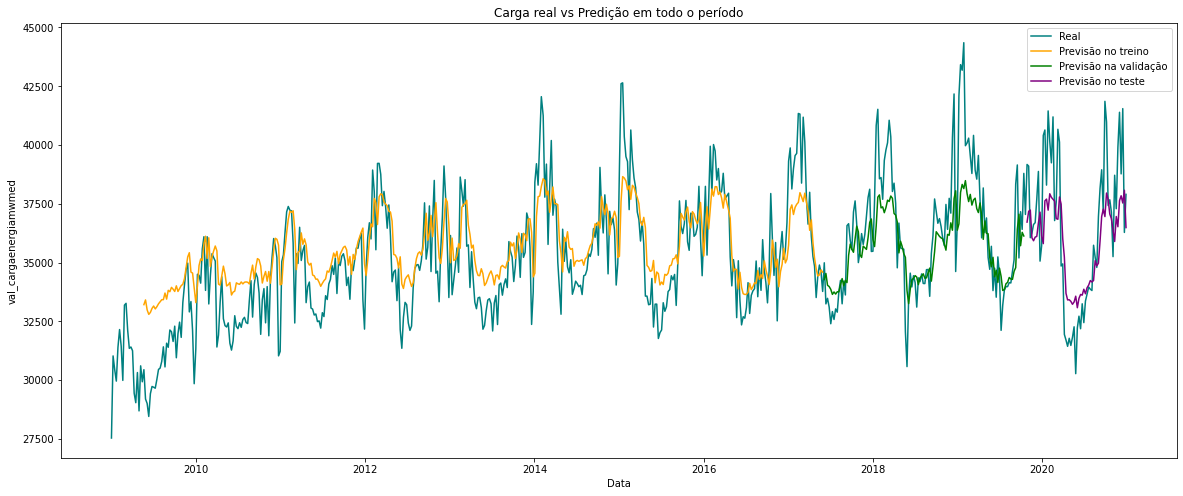

In [365]:
# indexes of each set of data
train_ix = pred_result['Data'] < date_val
val_ix = (pred_result['Data']>date_val) & (pred_result['Data']<date_test)
test_ix = pred_result['Data']>date_test

fix,ax=plt.subplots(figsize=(20, 8))

# plot measured data
sns.lineplot(x = df_target['Data'], 
             y = df_target[load_col], ax=ax, color = 'teal')

# plot predicted training data
for ix, color in zip([train_ix, val_ix, test_ix],['orange','green','purple']):
  sns.lineplot(x = pred_result.loc[ix].Data,
               y = pred_result.loc[ix].Carga_prev, 
               ax=ax, color=color)

plt.title('Carga real vs Predição em todo o período')
plt.legend(['Real', 'Previsão no treino', 'Previsão na validação', 'Previsão no teste'])

# Save model weights

In [ ]:
# Save the entire model to a HDF5 file.
# The '.h5' extension indicates that the model should be saved to HDF5.
model.save('LSTM.h5') 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# CONSERTAR A NORMALIZAÇÃO PRA MÉDIA MÓVEL